In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, random_unitary

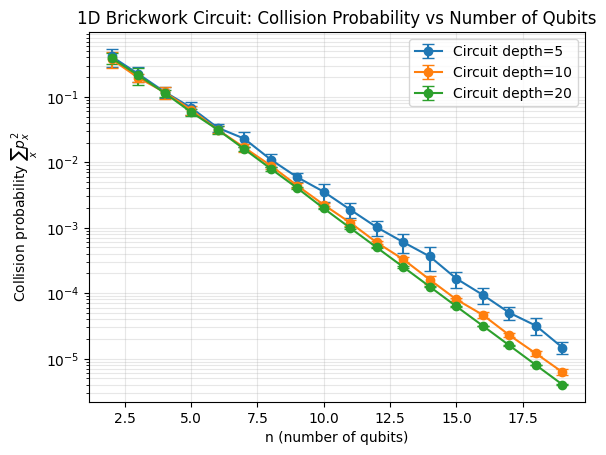

In [14]:
def build_circuit(n, d):
    qc = QuantumCircuit(n)

    for layer in range(d):
        start = layer % 2
        for i in range(start, n - 1, 2):
            qc.append(random_unitary(4), [i, i + 1])
    return qc

def collision_prob(qc):
    psi = Statevector.from_instruction(qc)
    probs = psi.probabilities()
    cp = np.sum(probs**2)

    return cp

depth = [5,10,20]
num_qubits = list(range(2, 20))
samples_per_n = 20

for d in depth:
    avg_prob = []
    std_prob = []
    for n in num_qubits:
        vals = []
        for _ in range(samples_per_n):
            qc = build_circuit(n, d)
            cp = collision_prob(qc)
            vals.append(cp)

        avg_prob.append(np.mean(vals))
        std_prob.append(np.std(vals))

    plt.errorbar(num_qubits, avg_prob, yerr=std_prob, marker='o', capsize=4, label=f'Circuit depth={d}')

plt.yscale('log')
plt.xlabel("n (number of qubits)")
plt.ylabel(r"Collision probability $\sum_x p_x^2$")
plt.title("1D Brickwork Circuit: Collision Probability vs Number of Qubits")
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()